In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [13]:
def load_netflix_data(filepath, max_rows=2000000):
    movie_id = None
    rows = []
    count = 0

    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if line.endswith(':'):
                movie_id = int(line[:-1])
            else:
                if count >= max_rows:
                    break
                user_id, rating, date = line.split(',')
                rows.append([int(user_id), movie_id, int(rating), date])
                count += 1

    df = pd.DataFrame(rows, columns=['user_id', 'movie_id', 'rating', 'date'])
    return df

# Change this path to where your file actually is
filepath = 'combined_data_1.txt'

print("Loading data... this may take a minute")
df = load_netflix_data(filepath, max_rows=2000000)
print(f"Done! Loaded {len(df):,} rows")
print(df.head())

Loading data... this may take a minute
Done! Loaded 2,000,000 rows
   user_id  movie_id  rating        date
0  1488844         1       3  2005-09-06
1   822109         1       5  2005-05-13
2   885013         1       4  2005-10-19
3    30878         1       4  2005-12-26
4   823519         1       3  2004-05-03


In [14]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nRating range:", df['rating'].min(), "to", df['rating'].max())
print("Unique users:", df['user_id'].nunique())
print("Unique movies:", df['movie_id'].nunique())


Shape: (2000000, 4)

Data types:
 user_id     int64
movie_id    int64
rating      int64
date          str
dtype: object

Missing values:
 user_id     0
movie_id    0
rating      0
date        0
dtype: int64

Rating range: 1 to 5
Unique users: 342445
Unique movies: 361


In [15]:
# Cell 4 - Load movie titles (handles commas in movie names)
movies = pd.read_csv('movie_titles.csv',
                      encoding='latin-1',
                      header=None,
                      names=['movie_id', 'year', 'title'],
                      on_bad_lines='warn',   # skip problem lines instead of crashing
                      engine='python')

print(f"Total movies loaded: {len(movies)}")
print(movies.head(10))

Total movies loaded: 17434
   movie_id    year                         title
0         1  2003.0               Dinosaur Planet
1         2  2004.0    Isle of Man TT 2004 Review
2         3  1997.0                     Character
3         4  1994.0  Paula Abdul's Get Up & Dance
4         5  2004.0      The Rise and Fall of ECW
5         6  1997.0                          Sick
6         7  1992.0                         8 Man
7         8  2004.0    What the #$*! Do We Know!?
8         9  1991.0      Class of Nuke 'Em High 2
9        10  2001.0                       Fighter


In [16]:
df = df.merge(movies[['movie_id', 'title']], on='movie_id', how='left')
print("Merged! Sample:")
print(df.head())

Merged! Sample:
   user_id  movie_id  rating        date            title
0  1488844         1       3  2005-09-06  Dinosaur Planet
1   822109         1       5  2005-05-13  Dinosaur Planet
2   885013         1       4  2005-10-19  Dinosaur Planet
3    30878         1       4  2005-12-26  Dinosaur Planet
4   823519         1       3  2004-05-03  Dinosaur Planet


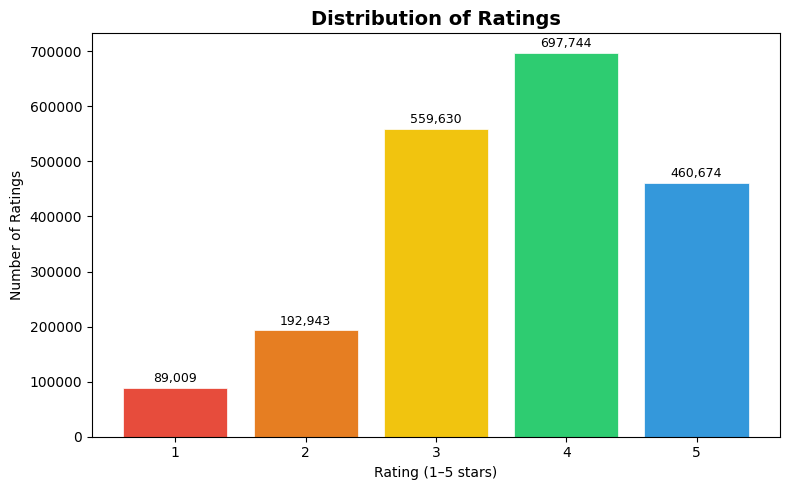

Saved as rating_distribution.png


In [17]:
plt.figure(figsize=(8, 5))
rating_counts = df['rating'].value_counts().sort_index()
bars = plt.bar(rating_counts.index, rating_counts.values, 
               color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'],
               edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.title('Distribution of Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating (1–5 stars)')
plt.ylabel('Number of Ratings')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150)
plt.show()
print("Saved as rating_distribution.png")

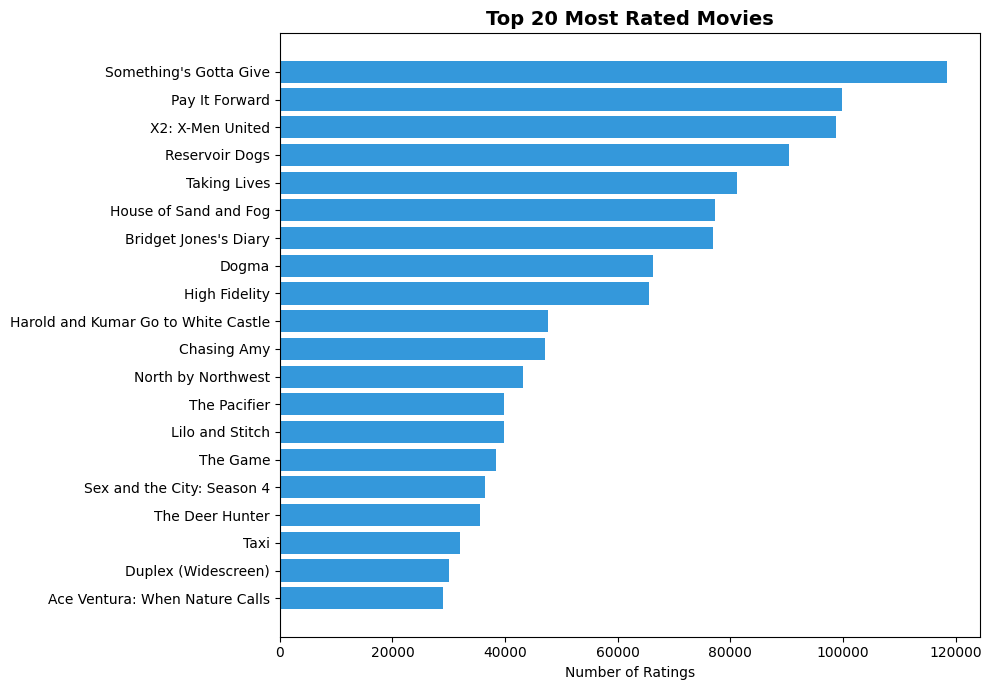

                                     num_ratings  avg_rating
title                                                       
Something's Gotta Give                    118413    3.761842
Pay It Forward                             99812    3.689346
X2: X-Men United                           98720    3.932202
Reservoir Dogs                             90450    4.003847
Taking Lives                               81260    3.478932
House of Sand and Fog                      77314    3.512378
Bridget Jones's Diary                      76944    3.706644
Dogma                                      66266    3.587858
High Fidelity                              65477    3.710127
Harold and Kumar Go to White Castle        47651    3.584500
Chasing Amy                                47167    3.622024
North by Northwest                         43122    4.157901
The Pacifier                               39875    3.557643
Lilo and Stitch                            39752    3.823254
The Game                

In [18]:
top_movies = df.groupby('title').agg(
    num_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean')
).sort_values('num_ratings', ascending=False).head(20)

plt.figure(figsize=(10, 7))
bars = plt.barh(top_movies.index[::-1], top_movies['num_ratings'][::-1], color='#3498db')
plt.xlabel('Number of Ratings')
plt.title('Top 20 Most Rated Movies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_movies.png', dpi=150)
plt.show()
print(top_movies.to_string())

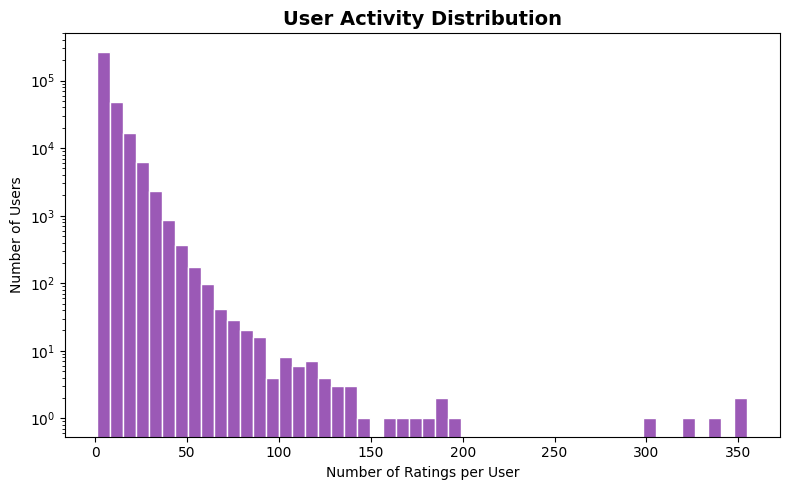

Average ratings per user: 5.8
Median ratings per user: 3.0
Max ratings by one user: 355


In [19]:
user_activity = df.groupby('user_id')['rating'].count()

plt.figure(figsize=(8, 5))
plt.hist(user_activity, bins=50, color='#9b59b6', edgecolor='white')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Number of Users')
plt.title('User Activity Distribution', fontsize=14, fontweight='bold')
plt.yscale('log')  # log scale because most users rate very few movies
plt.tight_layout()
plt.savefig('user_activity.png', dpi=150)
plt.show()

print(f"Average ratings per user: {user_activity.mean():.1f}")
print(f"Median ratings per user: {user_activity.median():.1f}")
print(f"Max ratings by one user: {user_activity.max()}")

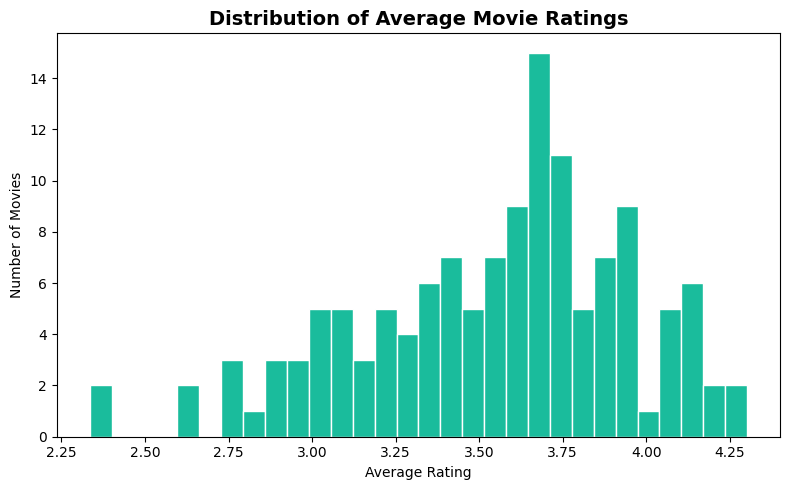

In [20]:
movie_avg = df.groupby('title').agg(
    avg_rating=('rating', 'mean'),
    num_ratings=('rating', 'count')
).reset_index()

# Only movies with at least 1000 ratings (more reliable average)
movie_avg_filtered = movie_avg[movie_avg['num_ratings'] >= 1000]

plt.figure(figsize=(8, 5))
plt.hist(movie_avg_filtered['avg_rating'], bins=30, color='#1abc9c', edgecolor='white')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.title('Distribution of Average Movie Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('avg_rating_dist.png', dpi=150)
plt.show()

In [21]:
total_users = df['user_id'].nunique()
total_movies = df['movie_id'].nunique()
total_ratings = len(df)
total_possible = total_users * total_movies
sparsity = (1 - total_ratings / total_possible) * 100

print("=" * 45)
print("        DATASET SUMMARY")
print("=" * 45)
print(f"Total ratings loaded  : {total_ratings:>12,}")
print(f"Unique users          : {total_users:>12,}")
print(f"Unique movies         : {total_movies:>12,}")
print(f"Total possible pairs  : {total_possible:>12,}")
print(f"Sparsity              : {sparsity:>11.2f}%")
print("=" * 45)

        DATASET SUMMARY
Total ratings loaded  :    2,000,000
Unique users          :      342,445
Unique movies         :          361
Total possible pairs  :  123,622,645
Sparsity              :       98.38%


## Key Business Insights from EDA

1. Positive rating bias: Most users give 4-star ratings, suggesting users tend 
   to rate movies they already liked — they avoid watching movies they'd hate.

2. High data sparsity: Over 99% of possible user-movie pairs have no rating. 
   This makes recommendation hard — the model must generalize from very little data.

3. Power-law user activity: A small % of highly active users contribute a 
   disproportionate number of ratings. 80% of users have rated fewer than 50 movies.

4. Popular movie concentration: A small set of movies (like popular titles) 
   receive the vast majority of ratings. Most movies have very few ratings — 
   this creates a "cold start" problem for lesser-known content.

5. Implication for recommendation: Collaborative filtering will work well for 
   popular movies and active users, but will struggle with new or niche content.